In [1]:
from src import helpers
import numpy as np

In [2]:
text_file = 'data/raw/POP_ECG_EDA_Versie_B-112-1.txt'
out_file = 'data/processed/POP_ECG_EDA_Versie_B-112-1.csv'

eprime_df = helpers.eprime_txt_to_csv(text_file=text_file,csv_file=out_file,save_file=False)

corrected_eprime_df, biopac_col = helpers.get_corrected_eprime_df(eprime_df=eprime_df)

corrected_eprime_df.head()



,ID_BIOPAC,Procedure,CorrectResponse,StimType,Task,TrialListLexicalPrac,StimuliLexPrac,WordPrac,StimulusWordPrac,Running,...,Instruction.OnsetDelay,Instruction.OnsetTime,Instruction.DurationError,Instruction.OnsetToOnsetTime,PMInstruction1.DEVICE,PMInstruction2.DEVICE,PMInstruction3.DEVICE,PMInstruction4.DEVICE,PMInstruction5.DEVICE,ThankYou.DEVICE
32,0,TrialProcOTLexical1,2,Nonword,NaN,NaN,NaN,NaN,NaN,TrialListOTLexical1,...,12,2641268,-999999,0,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard
33,1,TrialProcOTLexical1,1,PM_1,NaN,NaN,NaN,NaN,NaN,TrialListOTLexical1,...,12,2641268,-999999,0,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard
34,2,TrialProcOTLexical1,1,Word,NaN,NaN,NaN,NaN,NaN,TrialListOTLexical1,...,12,2641268,-999999,0,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard
35,3,TrialProcOTLexical1,2,Nonword,NaN,NaN,NaN,NaN,NaN,TrialListOTLexical1,...,12,2641268,-999999,0,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard
36,4,TrialProcOTLexical1,1,Lure_1,NaN,NaN,NaN,NaN,NaN,TrialListOTLexical1,...,12,2641268,-999999,0,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard,Keyboard


In [3]:
corrected_journal_file = helpers.get_corrected_journal_df(journal_file_path=r'data\raw\Journal_112.xls',biopac_col=biopac_col,show_rows_from=1)
corrected_journal_file.head()

*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'


,ID_BIOPAC,Time,Type,Channel,Label,Date Created
0,0,0.000 sec,Append,Global,"Segment 1 Wed Dec 10 2025 10:05:01.167, MP160 ...",2025/12/10 10:05:01.167
1,1,880.369 sec,Stimulus Delivery,Global,130,2026/03/20 15:31:25.528
2,2,883.663 sec,Stimulus Delivery,Global,129,2026/03/20 15:31:25.586
3,3,886.824 sec,Stimulus Delivery,Global,129,2026/03/20 15:31:25.590
4,4,890.653 sec,Stimulus Delivery,Global,130,2026/03/20 15:31:25.598


In [4]:
# try to merge


print("range of values in biopac id column for journal file",min(corrected_journal_file[f"{biopac_col}"]),max(corrected_journal_file[f"{biopac_col}"]))
print("range of values in biopac id column for eprime file",min(corrected_eprime_df[f"{biopac_col}"]),max(corrected_eprime_df[f"{biopac_col}"]))


range of values in biopac id column for journal file 0 784
range of values in biopac id column for eprime file 0 783


Text(0.5, 1.0, 'range of vals:(0, 783) ')

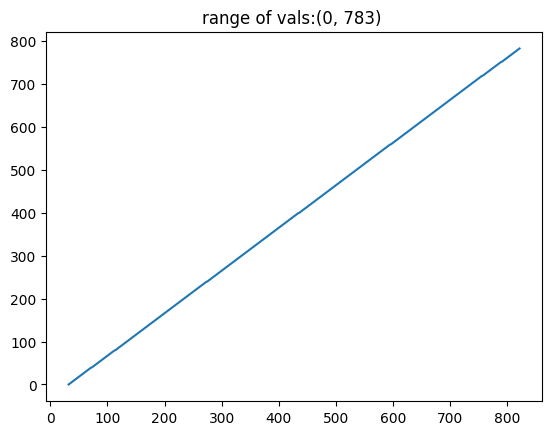

In [5]:
from matplotlib import pyplot as plt

plt.plot(corrected_eprime_df[f"{biopac_col}"])
plt.title(f"range of vals:{min(corrected_eprime_df[f"{biopac_col}"]),max(corrected_eprime_df[f"{biopac_col}"])} ")

In [6]:
import pandas as pd
df = pd.read_csv(r'data\processed\POP_ECG_EDA_Versie_B-112-1.csv')
df.to_excel(r'data\processed\POP_ECG_EDA_Versie_B-112-1.xlsx')